In [1]:
# Loading libraries 
import pandas as pd
import re
import calendar
import folium
import geopandas as gpd
import seaborn as sns
from shapely.geometry import Point
import matplotlib.pyplot as plt
from folium.plugins import HeatMap

In [2]:
# Import raw_CSV obtained from USGS with filter mag>4.0
df = pd.read_csv(r'data\earthquake_1990_2023.csv')
df.columns

Index(['time', 'latitude', 'longitude', 'depth', 'mag', 'magType', 'nst',
       'gap', 'dmin', 'rms', 'net', 'id', 'updated', 'place', 'type',
       'horizontalError', 'depthError', 'magError', 'magNst', 'status',
       'locationSource', 'magSource'],
      dtype='object')

## Part 1 Data Wrangling

Before analyzing anything, verify the dataset structure and confirm that key fields exist and are readable:
- Event time (for temporal analysis)
- Latitude/longitude (for mapping)
- Magnitude and depth (for severity/impact context)
- Place/region text (for interpretability)

At this stage, the goal to understand what is available, what is missing, and what needs normalization.

In [3]:
# Drop unwanted columns
columns_to_drop = ['nst', 'gap', 'dmin', 'rms', 'id', 'updated', 'type','horizontalError', 'depthError', 'magError', 'magNst', 'status', 'locationSource', 'magSource']
df_clean = df.drop(columns=columns_to_drop)

In [4]:
df_clean.shape

(16836, 8)

In [5]:
# Function to extract epicenter location and country/region
def extract_location_country(place):
    match = re.match(r"(\d+ km [A-Z]+ of .+), (.+)", place)
    if match:
        return match.group(1), match.group(2)
    elif 'region' in place or ',' not in place:
        return None, place
    else:
        return None, place

In [6]:
# Apply the function to extract data into two new columns
df_clean['epi_location'], df_clean['epi_country'] = zip(*df_clean['place'].apply(extract_location_country))

In [7]:
# Convert the time column to a datetime format
df_clean['time'] = pd.to_datetime(df_clean['time'])
# Extract year, month, day, and time of day into separate columns
df_clean['year'] = df_clean['time'].dt.year
df_clean['month'] = df_clean['time'].dt.month
df_clean['day'] = df_clean['time'].dt.day
df_clean['time_day'] = df_clean['time'].dt.strftime('%H:%M:%S')

In [9]:
missing_percentage = df_clean.isnull().mean() * 100
missing_percentage

time             0.000000
latitude         0.000000
longitude        0.000000
depth            0.000000
mag              0.000000
magType          0.000000
net              0.000000
place            0.000000
epi_location    28.545973
epi_country      0.000000
year             0.000000
month            0.000000
day              0.000000
time_day         0.000000
dtype: float64

We see that `epi_location` has ~28.5% missing values, while most other core fields (time, lat/lon, depth, magnitude) are complete. This may be due to USGS `place` strings are not perfectly standardized. Many records describe tectonic features or broad regions (e.g., ridges, rises, ocean basins) that don’t match a sovereign boundary. It often includes tectonic features (ridges/rises), ocean regions, islands, or multi-country border phrases.

As such, I standardize `epi_country` using manual mappings for common ridge/ocean feature strings (“Pacific Ocean”, “Indian Ocean”, etc.), U.S. state detection (because many USGS strings end with a state name)and comma parsing to extract the last segment as a likely country (e.g., “northern Qinghai, China” → “China”)

In [10]:
# Function to extract country or region from epi_location
def extract_country_region(epi_country):
    # Check if None
    if epi_country is None:
        return None  

    # Define manual mappings for specific cases
    manual_mappings = {
    # Oceanic ridges and regions
    'southeast Indian Ridge': 'Indian Ocean',
    'southern East Pacific Rise': 'Pacific Ocean',
    'West Chile Rise': 'Pacific Ocean',
    'northern Mid-Atlantic Ridge': 'Atlantic Ocean',
    'southern Mid-Atlantic Ridge': 'Atlantic Ocean',
    'Pacific-Antarctic Ridge': 'Pacific Ocean',
    'Indian Ocean Triple Junction': 'Indian Ocean',
    'Mid-Indian Ridge': 'Indian Ocean',
    'southern East Pacific Rise': 'Pacific Ocean',
    'central Mid-Atlantic Ridge': 'Atlantic Ocean',
    'Carlsberg Ridge': 'Indian Ocean',
    'Owen Fracture Zone region': 'Indian Ocean',
    'Drake Passage': 'Southern Ocean',
    'Tristan da Cunha region': 'Atlantic Ocean',
    'western Indian-Antarctic Ridge': 'Indian Ocean',
    'Reykjanes Ridge': 'Atlantic Ocean',
    'Svalbard and Jan Mayen': 'Norway',
    'Bay of Bengal': 'Indian Ocean',
    'Sea of Okhotsk': 'Russia',
    'Galapagos Triple Junction region': 'Pacific Ocean',
    'Cabo Verde': 'Cape Verde',
    "D'Entrecasteaux Islands region": 'Papua New Guinea',
    "Monte Cristo Range, NV Earthquake": "United States",
    'Philippine Islands region': 'Philippines',
    "off the west coast of northern Sumatra": "Indonesia",
    'east central Pacific Ocean': 'Pacific Ocean',
    'Kermadec Islands region': 'New Zealand', 
    'Southwest Indian Ridge': 'Indian Ocean',
    'Azores-Cape St. Vincent Ridge': 'Atlantic Ocean',
    'south of Africa': 'South Atlantic Ocean',

    # Islands and island regions
    'South Sandwich Islands region': 'United Kingdom',
    'Bouvet Island region': 'Norway',
    'Balleny Islands region': 'New Zealand',
    'Macquarie Island region': 'Australia',
    'Pitcairn Islands region': 'United Kingdom',
    'Azores Islands region': 'Portugal',
    'Prince Edward Islands region': 'South Africa',
    'Mariana Islands region': 'United States',
    'Fox Islands': 'United States',
    'Falkland Islands region': 'United Kingdom',
    'Saint Helena': 'United Kingdom',
    'South Shetland Islands': 'Antarctica',
    'Easter': 'Chile',
    'Easter Island region': 'Chile',
    'Kuril Islands': 'Russia',
    'Northern Mariana Islands': 'United States',
    'Jan Mayen Island region': 'Norway',  
    'Baffin Bay': 'Arctic Ocean',  
    'Antofagasta': 'Chile',  
    'Barbados': 'Barbados',  
    'Yap': 'Micronesia',  
    'Cayman Islands': 'United Kingdom',
    'Guadeloupe': 'France',
    'Kerguelen Islands region': 'France',
    'Samoa Islands region': 'Samoa',
    'Crozet Islands region': 'France',
    'South Georgia Island region': 'United Kingdom',
    'south of the Fiji Islands': 'Pacific Ocean',
    'southeast of the Loyalty Islands': 'Pacific Ocean',
    'northern East Pacific Rise': 'Pacific Ocean',
    'Ascension': 'United Kingdom',
    'Windward Islands': 'West Indies',
    'Grenada' : 'West Indies',
    
    # Geographic regions and countries
    'Japan region': 'Japan',
    'Tonga region': 'Tonga',
    'New Zealand region': 'New Zealand',
    'Guam region': 'United States',
    'Russia region': 'Russia',
    'Svalbard region': 'Norway',  
    'north of Svalbard': 'Norway',
    'Saint Helena': 'Saint Helena',  
    "near the north coast of Greenland": "Greenland",
    "southwest of Africa": "South Atlantic Ocean",
    "northwest of Australia": "Indian Ocean",
    'near the coast of Nicaragua': 'Nicaragua' ,
    'south of Tonga': 'Tonga',
    'South Sudan': 'Sudan',
    'U.S. Virgin Islands': 'United States',
    'North Macedonia': 'Macedonia',
    'south of Australia': 'Australia',
    'central Peru':'Peru',
    'Puerto Rico region': 'Puerto Rico',
    'southern Iran': 'Iran',
    'central Italy': 'Italy',
    'north of Honduras': 'Honduras',
    'eastern Turkey': 'Turkey',
    'Aisen': 'Chile', 
    'south of Panama': 'Pacific Ocean',
    'Cape Verde': 'Cape Verde',  
    'Ross Sea': 'Antarctica',  
    'Severnaya': 'Russia',    
    
    # Earthquake-specific names
    "2004 Sumatra - Andaman Islands Earthquake": "Indonesia",
    "Kahramanmaras earthquake sequence": "Turkey",
    
    # Border and coastal regions
    "Peru-Ecuador border region": ["Peru", "Ecuador"],
    'Chile-Bolivia border region': ['Chile', 'Bolivia'],
    'Turkey-Syria border region': ['Turkey', 'Syria'],
    'Chile-Argentina border region': ['Chile', 'Argentina'], 
    'Turkmenistan-Iran border region': ['Turkmenistan', 'Iran'],
    'Mauritius - Reunion region': ['Mauritius', 'France'],
    'Turkey-Iraq border region': ['Turkey', 'Iraq'],
    'Tajikistan-Xinjiang border region': ['Tajikistan', 'China'],
    'Serbia-Bulgaria-Macedonia border region': ['Serbia', 'Bulgaria', 'North Macedonia'],
    'Afghanistan-Tajikistan-Pakistan region': ['Afghanistan', 'Tajikistan', 'Pakistan'],
    'Strait of Gibraltar': ['Spain', 'Morocco'],
    "near the coast of Ecuador": "Ecuador",
    "near the coast of Guatemala": "Guatemala",
    'near the west coast of Colombia': 'Colombia',
    'near the north coast of New Guinea, Papua New Guinea': 'Papua New Guinea',
    'near the north coast of Papua, Indonesia': 'Indonesia',
    'south of the Kermadec Islands': 'New Zealand',
    
    # Miscellaneous locations
    "Central Afghanistan": "Afghanistan",
    "Central Turkey": "Turkey",
    "CA": "United States",  
    "Michoacan": "Mexico",  
    "Bio-Bio": "Chile",
    "Gabon": "Gabon",
    "Ferndale": "United States",
    'Chagos Archipelago region': 'United Kingdom', 
    "Santa Cruz Islands": "Solomon Islands",  
    "Franz": "Russia",  
    "Grenada": "Grenada",  
    "Petrolia": "United States",  
    "Ridgecrest Earthquake Sequence": "United States",
    'Haiti region': 'Haiti',
    'Mexico Earthquake': 'Mexico',
    'Bali': 'Indonesia',
    'western Xizang': 'China',
    'Delta': 'United States',
    'Xizang-Qinghai border region': 'China',
    'Ascension Island region': 'United Kingdom',  
    'Revilla Gigedo Islands region': 'Mexico', 
    'Mayotte': 'France',   
    "near the south coast of western Honshu, Japan": "Japan",
    "western Honshu, Japan": "Japan",
    "Honshu": "Japan",
    'South Island of New Zealand' : 'New Zealand',
    'south of New Zealand': 'New Zealand',
    'northwestern Kashmir': 'Kashmir',
    'Ascension Island region': 'United Kingdom', 
    'Revilla Gigedo Islands region': 'Mexico',  
    'Mayotte': 'France', 
    "Antofagasta": "Chile",  
    "Santa Cruz Islands": "Solomon Islands", 
    'northern Algeria': 'Algeria',

}

    # List of U.S. states to map to "United States"
    us_states = [
        "California", "Oregon", "Washington", "Nevada", "Idaho", "Montana", 
        "Utah", "Wyoming", "Arizona", "Colorado", "New Mexico", "Texas",
        "Alaska", "Hawaii", "Virginia", "Oklahoma"
    ]

    # Check if epi_location matches any manual mapping
    for key, value in manual_mappings.items():
        if key in epi_country:
            return value

    # Handle U.S. states
    for state in us_states:
        if state in epi_country:
            return "United States"

    # Handle cases with distance-based descriptions (e.g., "3km NE of Yucca Valley, California")
    match = re.search(r'of (.+?),? ([A-Za-z\s\-]+)', epi_country)
    if match:
        location = match.group(1).strip()
        # Extract the part after the last comma if present
        if ',' in location:
            return location.split(',')[-2].strip()
        return location

    # Handle cases with commas (e.g., "northern Qinghai, China")
    if ',' in epi_country:
        location = epi_country.split(',')[-1].strip()
        if location in us_states:
            return "United States"
        return location

    # Return location as-is if no further processing is possible
    return epi_country.strip()

In [12]:
# Apply the updated function to epi_location column
df_clean['country'] = df_clean['epi_country'].apply(extract_country_region)

# Function to ensure all values in the 'country' column are hashable
def make_hashable(value):
    if isinstance(value, list):  
        return ", ".join(value)  
    return value  

# Apply the function to the 'country' column
df_clean['country'] = df_clean['country'].apply(make_hashable)

In [13]:
# Define and apply a function to categorize magnitudes
def categorize_magnitude(mag):
    if 5.0 <= mag <= 5.9:
        return 'moderate'
    elif 6.0 <= mag <= 6.9:
        return 'strong'
    elif 7.0 <= mag <= 7.9:
        return 'major'
    else:
        return 'great'

df_clean['category'] = df_clean['mag'].apply(categorize_magnitude)

# Categorize 'time_day' into time ranges
def categorize_time_of_day(hour):
    if 6 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 18:
        return 'Afternoon'
    elif 18 <= hour < 24:
        return 'Evening'
    else:
        return 'Night'

df_clean['hour'] = df_clean['time'].dt.hour
df_clean['time_day'] = df_clean['hour'].apply(categorize_time_of_day)

## Part 2 Statistical Analysis and Visualization

In [15]:
# Group by year and count the number of earthquakes per year
daily_eq_counts = df_clean.groupby(df_clean['time'].dt.date).size()
daily_eq_counts.head()

time
1990-01-02    2
1990-01-04    1
1990-01-05    3
1990-01-06    1
1990-01-07    1
dtype: int64

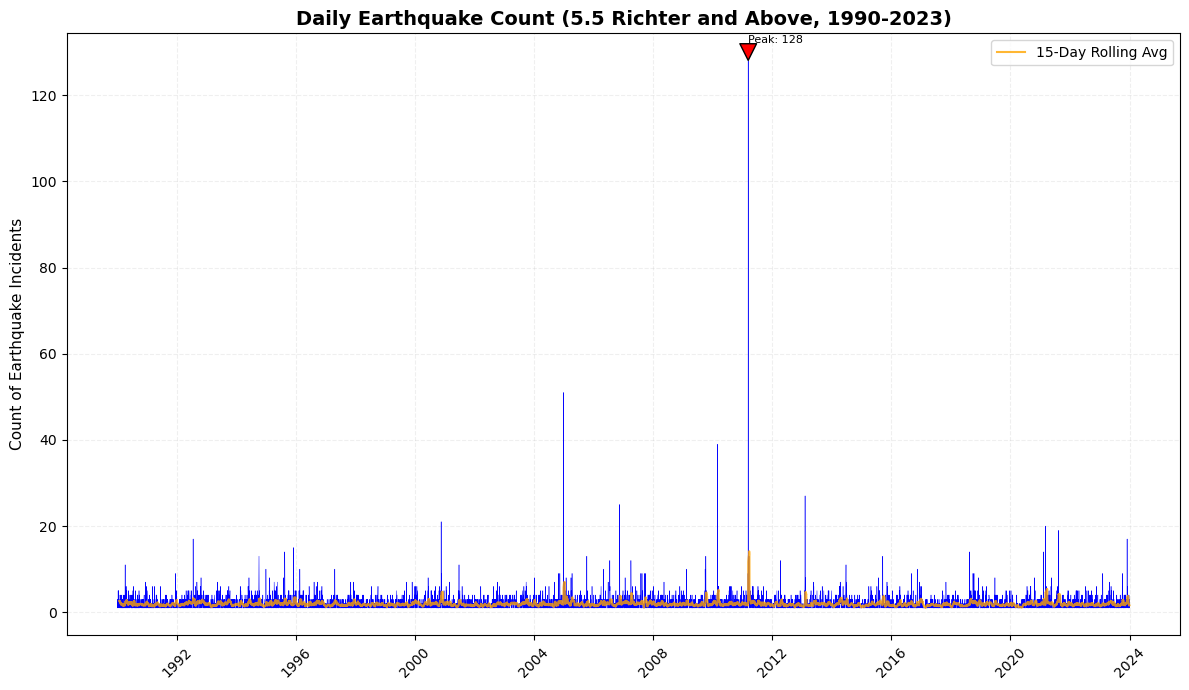

In [16]:
# Create a time series plot
plt.figure(figsize=(12, 7))
plt.plot(daily_eq_counts.index, daily_eq_counts.values, color='blue', linewidth=0.35)

# Add labels, title, and grid
plt.xlabel('', fontsize=11)
plt.ylabel('Count of Earthquake Incidents', fontsize=11)
plt.title('Daily Earthquake Count (5.5 Richter and Above, 1990-2023)', fontsize=14, weight='bold')
plt.grid(True, linestyle='--', alpha=0.2)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

rolling_avg = daily_eq_counts.rolling(window=15).mean()
plt.plot(daily_eq_counts.index, rolling_avg, color='orange', label='15-Day Rolling Avg',alpha=0.8)
plt.legend()

plt.annotate(f'Peak: {daily_eq_counts.max()}', 
             xy=(daily_eq_counts.idxmax(), daily_eq_counts.max()), 
             xytext=(daily_eq_counts.idxmax() , daily_eq_counts.max() + 4),
             arrowprops=dict(facecolor='red', shrink=0.02),
             fontsize=8)

# Show the plot
plt.tight_layout()
plt.show()

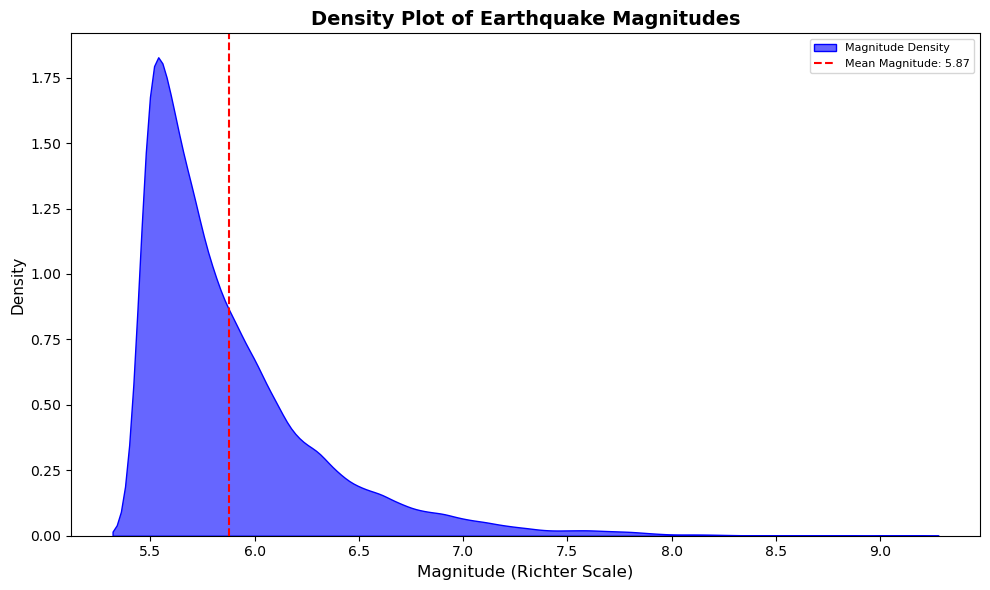

In [17]:
mean_magnitude = df_clean['mag'].mean()

# Create the density plot
plt.figure(figsize=(10, 6))
sns.kdeplot(df_clean['mag'], color='blue', fill=True, alpha=0.6, label='Magnitude Density')

# Add a vertical line for the mean magnitude
plt.axvline(mean_magnitude, color='red', linestyle='--', linewidth=1.5, label=f'Mean Magnitude: {mean_magnitude:.2f}')

# Add labels, title, and legend
plt.title('Density Plot of Earthquake Magnitudes', fontsize=14, weight='bold')
plt.xlabel('Magnitude (Richter Scale)', fontsize=12)
plt.ylabel('Density', fontsize=11)
plt.legend(fontsize=8)
plt.grid(False)
# Show the plot
plt.tight_layout()
plt.show()

## Part 3 Temporal Trend 
Investigate if there are any seasonal patterns or periodicities in monthly earthquake occurrences.
Identify whether certain months consistently experience higher or lower earthquake magnitudes.

In [19]:
# Aggregate total earthquakes per month and average magnitude
monthly_counts = df_clean.groupby('month').size()
monthly_max_magnitude = df_clean.groupby('month')['mag'].max()

# Combine into a single DataFrame for easier analysis
monthly_eq = pd.DataFrame({
    'Total Earthquakes': monthly_counts,
    'Maximum Magnitude': monthly_max_magnitude
})
monthly_eq

,Total Earthquakes,Maximum Magnitude
month,,
1,1356,8.1
2,1276,8.8
3,1540,9.1
4,1441,8.6
5,1385,8.3
6,1260,8.4
7,1356,8.2
8,1415,8.2
9,1431,8.4


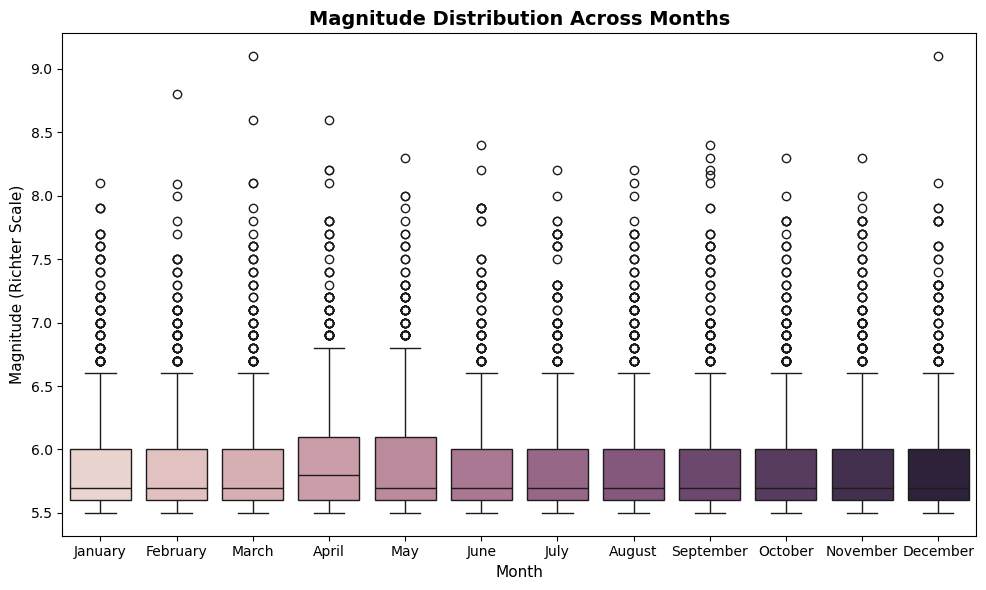

In [20]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='month', y='mag', hue='month', data=df_clean, legend=False )
plt.title('Magnitude Distribution Across Months', fontsize=14, weight='bold')
plt.xlabel('Month',fontsize=11)
plt.ylabel('Magnitude (Richter Scale)', fontsize=11)
plt.xticks(ticks=range(0, 12), labels=[calendar.month_name[m] for m in range(1, 13)])
plt.tight_layout()
plt.show()

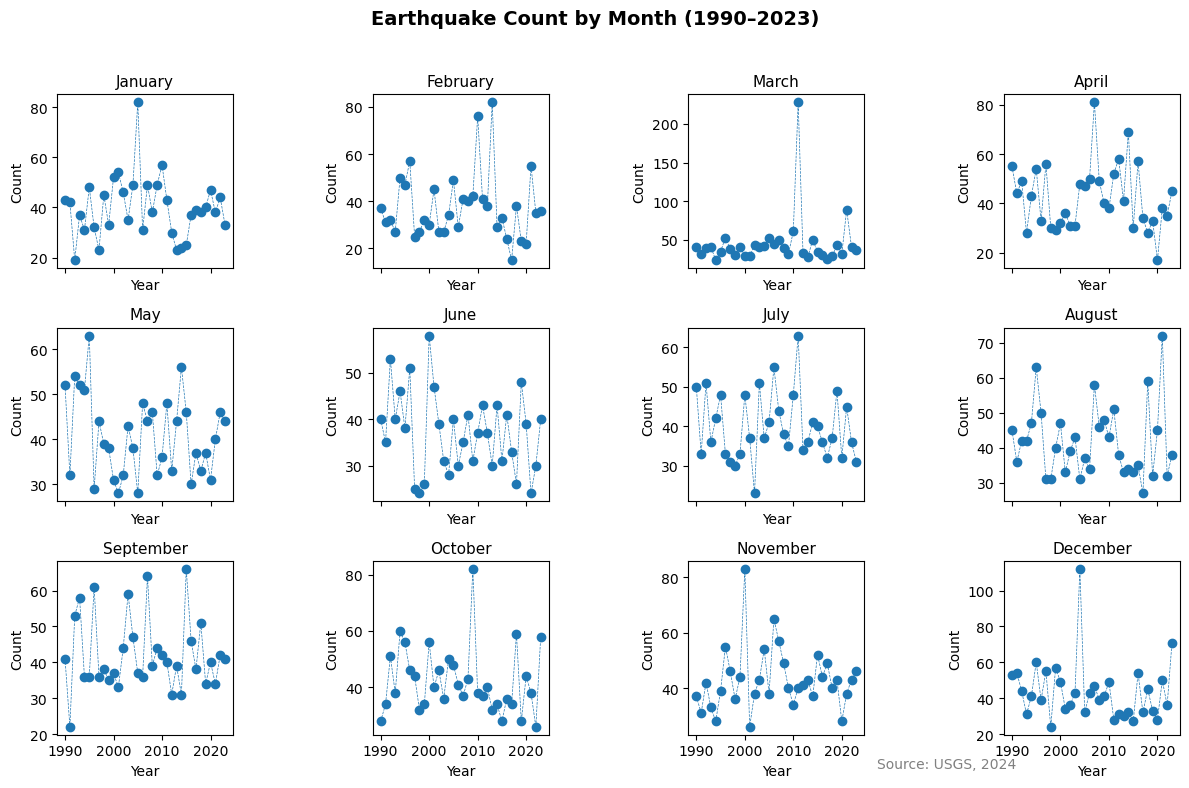

In [21]:
# Calculate the maximum magnitude for each month across all years
monthly_count = df_clean.groupby(['year', 'month'])['mag'].size().unstack()

# Create a 3x4 subplot for each month
fig, axes = plt.subplots(3, 4, figsize=(12, 8), sharex=True, sharey=False)
months = range(1, 13)

# Flatten axes for easier iteration
axes = axes.flatten()

# Plot each month's maximum magnitude over the years
for i, month in enumerate(months):
    axes[i].plot(
        monthly_count.index, 
        monthly_count[month], 
        marker='o', linestyle='--', linewidth=0.5
    )
    axes[i].set_title(calendar.month_name[month], fontsize=11)
    axes[i].set_xlabel('Year', fontsize=10)
    axes[i].set_ylabel('Count', fontsize=10)
    axes[i].grid(False)

plt.text(
    x=monthly_count.index[1],  
    y=min(monthly_count) - 0.20,  
    s="Source: USGS, 2024", 
    fontsize=10,
    color='gray',
    ha='right'  
)

# Adjust layout for better spacing
plt.suptitle('Earthquake Count by Month (1990–2023)', fontsize=14, weight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [22]:
from scipy.stats import f_oneway

# Perform ANOVA test on mothly magnitudes
anova_result = f_oneway(*[df_clean[df_clean['month'] == m]['mag'] for m in range(1, 13)])
print(f"ANOVA Test Result: F-statistic = {anova_result.statistic}, p-value = {anova_result.pvalue}") # non-significant

ANOVA Test Result: F-statistic = 1.0793337400095395, p-value = 0.3733672560080042


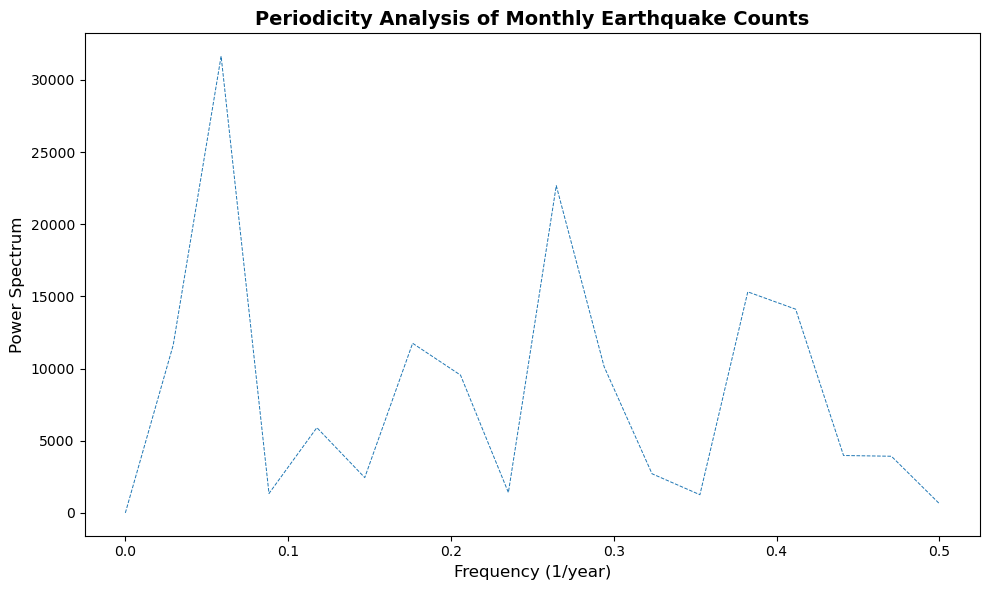

In [23]:
from scipy.signal import periodogram

# Calculate periodogram for monthly earthquake counts
frequencies, power_spectrum = periodogram(monthly_count.sum(axis=1))

# Plot the power spectrum
plt.figure(figsize=(10, 6))
plt.plot(frequencies, power_spectrum, linestyle='--', linewidth = 0.7)
plt.title('Periodicity Analysis of Monthly Earthquake Counts', fontsize=14, weight='bold')
plt.xlabel('Frequency (1/year)', fontsize=12)
plt.ylabel('Power Spectrum', fontsize=12)
plt.tight_layout()
plt.show()


In [24]:
# Find the Dominant Period
import numpy as np
from scipy.signal import periodogram

# Find the dominant frequency
dominant_frequency = frequencies[np.argmax(power_spectrum)]
dominant_period = 1 / dominant_frequency

print(f"Dominant Frequency: {dominant_frequency}")
print(f"Dominant Period: {dominant_period} (time units)")

Dominant Frequency: 0.058823529411764705
Dominant Period: 17.0 (time units)


The periodogram found that the ups-and-downs in your monthly totals line up most strongly with a pattern that repeats roughly once every 1.4 years, more than they line up with (for example) a 12‑month seasonal cycle.

### Seasonal Decomposition
Seasonal decomposition helps separate the time series into:
Trend: Long-term patterns.
Seasonal: Repeating patterns (e.g., monthly or yearly cycles).
Residual: Noise or irregularities.

<Figure size 1000x800 with 0 Axes>

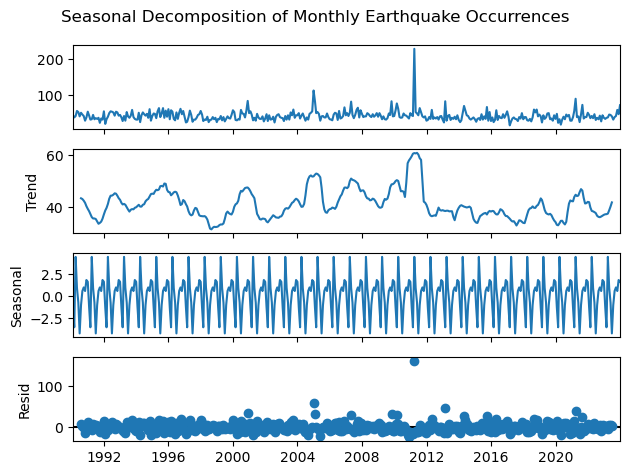

In [25]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Group by month and year to calculate monthly earthquake occurrences
monthly_counts = df_clean.groupby(pd.Grouper(key='time', freq='ME')).size()

# Perform seasonal decomposition
decomposition = seasonal_decompose(monthly_counts, model='additive', period=12)
# Plot the decomposition results
plt.figure(figsize=(10, 8))
decomposition.plot()
plt.suptitle('Seasonal Decomposition of Monthly Earthquake Occurrences', fontsize=12)
plt.tight_layout()
plt.show()

Classical decomposition shows a small, consistent annual component, but the residuals contain the dominant variability, indicating earthquake occurrence is primarily driven by episodic clustering rather than a strong seasonal cycle

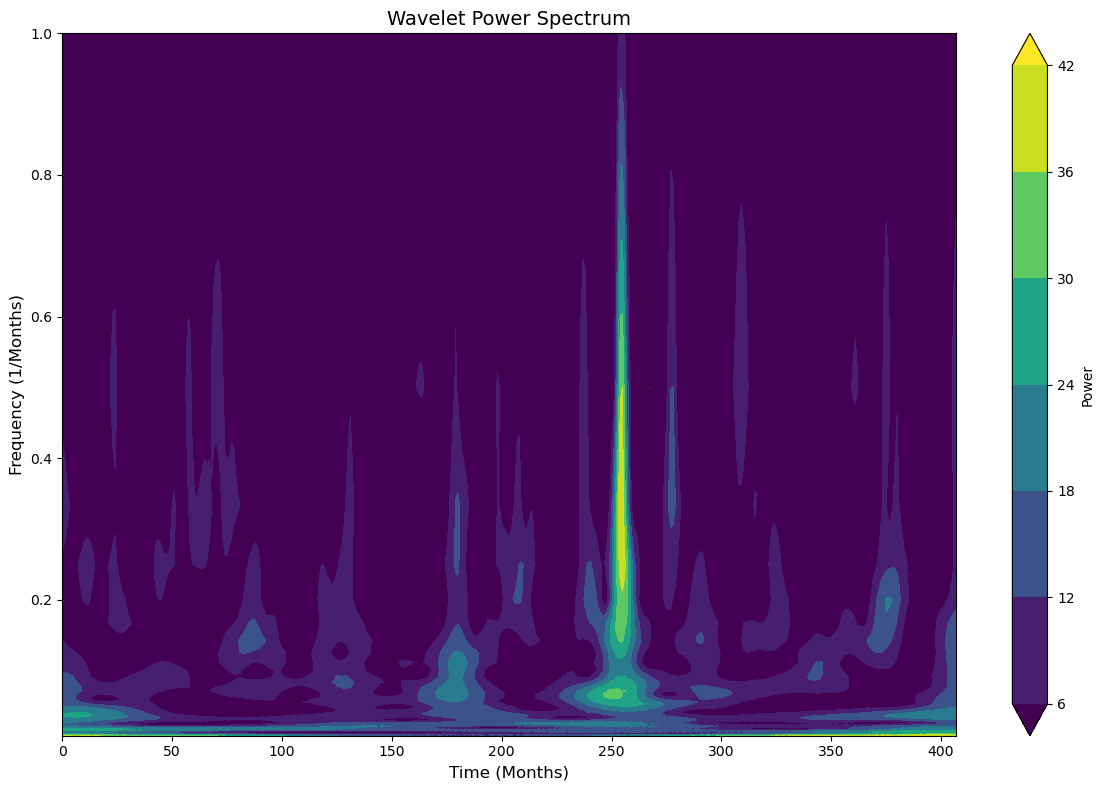

In [29]:
import pywt
import numpy as np

# Prepare data: Monthly earthquake occurrences
time_series = monthly_counts.values

# Perform Continuous Wavelet Transform (CWT)
scales = np.arange(1, 128)
wavelet = 'cmor1.5-1.0'
coefficients, frequencies = pywt.cwt(time_series, scales, wavelet)

# Plot wavelet power spectrum
plt.figure(figsize=(12, 8))
plt.contourf(np.arange(len(time_series)), frequencies, np.abs(coefficients), cmap='viridis', extend='both')
plt.title('Wavelet Power Spectrum', fontsize=14)
plt.xlabel('Time (Months)', fontsize=12)
plt.ylabel('Frequency (1/Months)', fontsize=12)
plt.colorbar(label='Power')
plt.tight_layout()
plt.show()

The wavelet spectrum highlights non-stationary behavior: periodic signals are not constant over the full time span, and the strongest energy occurs in short-lived windows consistent with clustered seismic episodes. Decomposition suggests annual seasonality exists but is small relative to residual spikes, the periodogram flags a dominant medium-term cycle in the full record, and the wavelet spectrum shows that much of the spectral energy is time-localized—consistent with clustered seismic episodes rather than a stable seasonal driver. 

## Part 4 Hypothesis Testing

Does earthquake occurs at night?
H0: The occurrence of major earthquakes (mag>8) is independent of the time of day
H1: The occurrence of major earthquakes (mag>8) is dependent of the time of day

In [33]:
crosstab = pd.crosstab(df_clean['time_day'], df_clean['category'])
print(crosstab)

category   great  major  moderate  strong
time_day                                 
Afternoon      7    125      2851    1144
Evening        8    129      2914    1178
Morning       10    120      2990    1173
Night         12    108      2917    1150


In [34]:
from scipy.stats import chi2_contingency

# Perform Chi-Square Test
chi2, p, dof, expected = chi2_contingency(crosstab)

# Print results
print(f"Chi-Square Statistic: {chi2}")
print(f"P-value: {p}") # non-significat

Chi-Square Statistic: 4.242854734155882
P-value: 0.8947136284398944


Interpretation: Fail to reject HO, earthquake magnitude category and time of day appear independent in this dataset.

## Part 4 Spatial Context

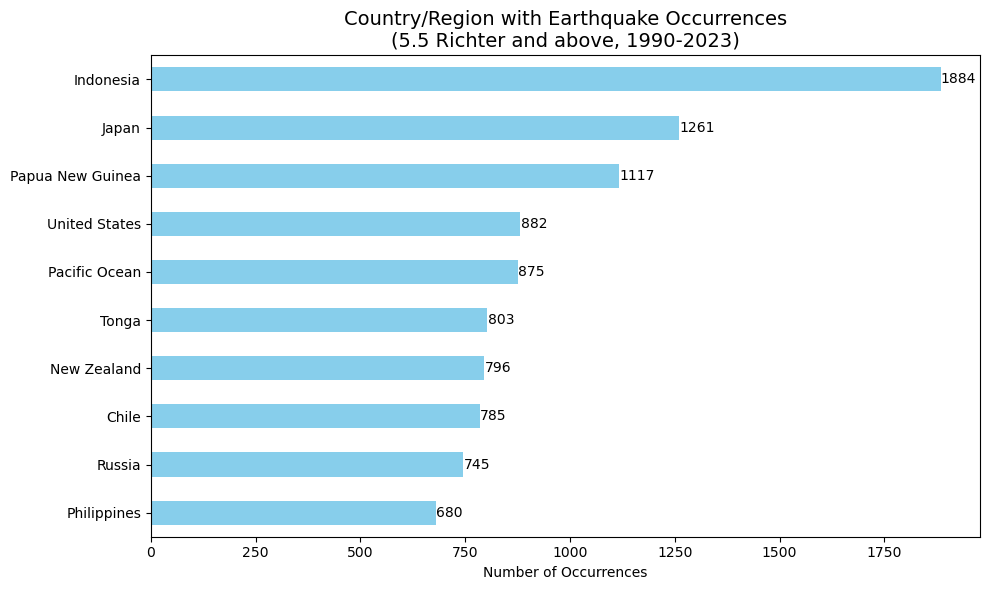

In [37]:
# Count occurrences of each country
eq_counts = df_clean['country'].value_counts()

# Select the top 10 countries with the highest occurrences
top_10_countries = eq_counts.head(10)

# Create a horizontal bar plot
plt.figure(figsize=(10, 6))
top_10_countries.plot(kind='barh', color='skyblue')

# Add labels and title
plt.xlabel('Number of Occurrences')
plt.ylabel('')
plt.title('Country/Region with Earthquake Occurrences\n(5.5 Richter and above, 1990-2023)', fontsize=14)

# Annotate the bars with counts
for index, value in enumerate(top_10_countries):
    plt.text(value + 1, index, str(value), va='center')  
    
# Invert the y-axis to show the highest value at the top
plt.gca().invert_yaxis()

# Show the plot
plt.tight_layout()
plt.show()

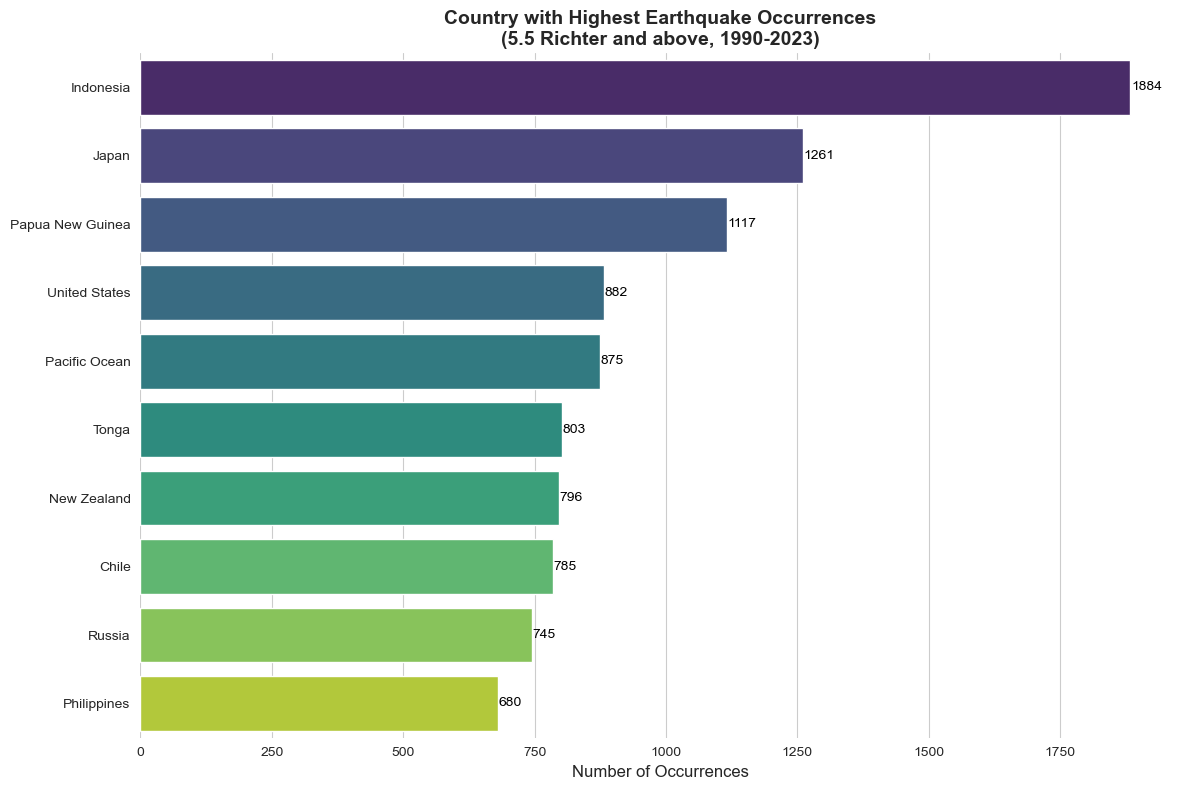

In [38]:
# Set a Seaborn style for better aesthetics
sns.set_style("whitegrid")
# Select the top 10 countries with the highest occurrences
top_10_countries = eq_counts.head(10).reset_index()
top_10_countries.columns = ['country', 'count']

# Create a horizontal bar plot with custom colors
plt.figure(figsize=(12, 8))
bars = sns.barplot(
    x='count', 
     y='country', 
    data=top_10_countries, 
    hue='country',  
    palette="viridis", 
    dodge=False, 
    legend=False  # Disable legend
)

# Add annotations (counts) on top of each bar
for index, value in enumerate(top_10_countries['count']):
    plt.text(value + 1, index, str(value), va='center', ha='left', fontsize=10, color='black')

# Add labels and title
plt.xlabel('Number of Occurrences', fontsize=12)
plt.ylabel('')
plt.title(
    'Country with Highest Earthquake Occurrences\n(5.5 Richter and above, 1990-2023)', 
    fontsize=14, weight='bold'
)

# Remove spines for a cleaner look
sns.despine(left=True, bottom=True)

# Adjust layout for better spacing
plt.tight_layout()

# Show the plot
plt.show()

## Part 6 Geovisualizations

<Figure size 1500x1000 with 0 Axes>

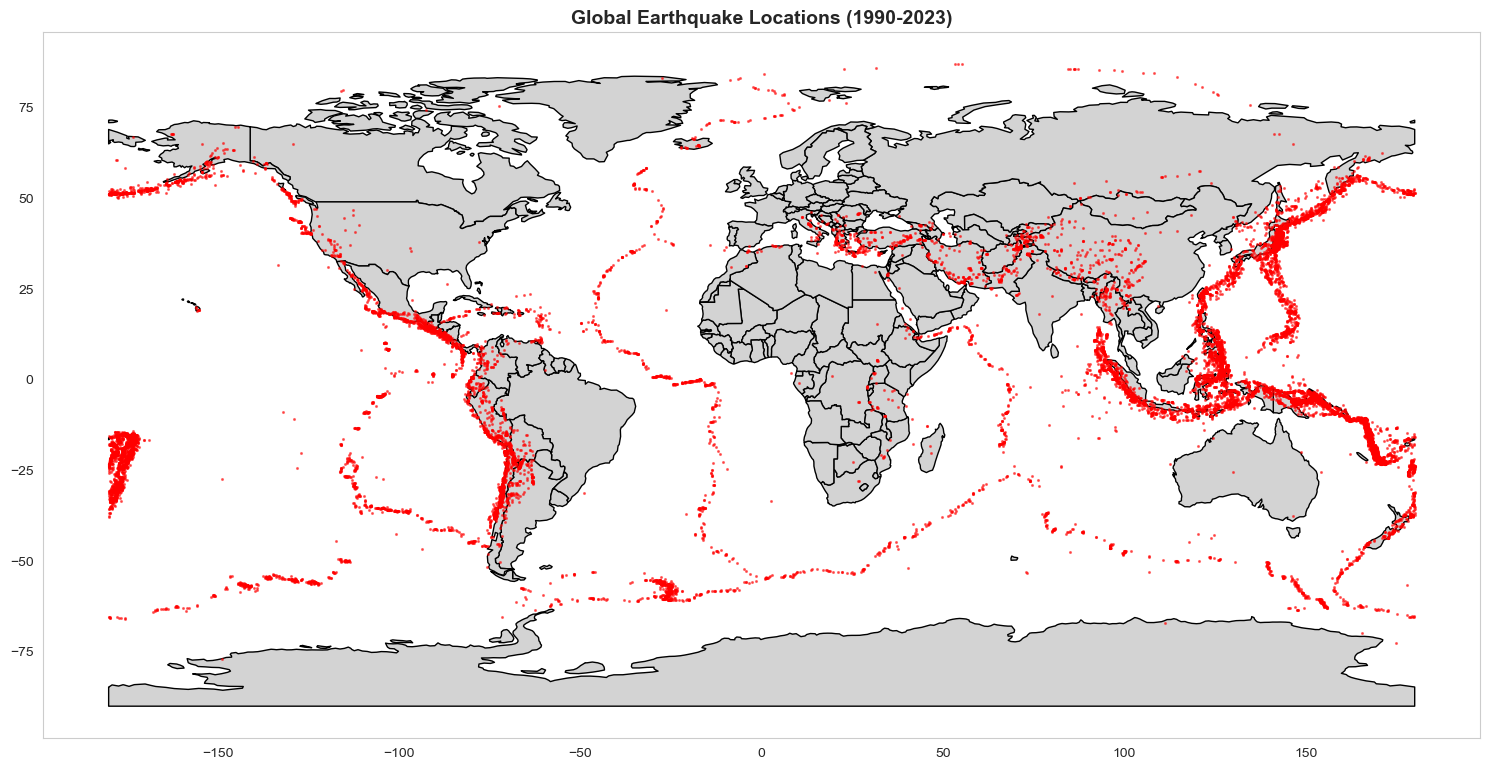

In [39]:
# Create a GeoDataFrame from df_clean
geometry = [Point(xy) for xy in zip(df_clean['longitude'], df_clean['latitude'])]
gdf = gpd.GeoDataFrame(df_clean, geometry=geometry)

world = gpd.read_file(r"C:\Users\pstha23\Documents\Python Scripts\ne_110m_admin_0_countries\ne_110m_admin_0_countries.shp")

# Plot the world map
plt.figure(figsize=(15, 10))
ax = world.plot(color='lightgray', edgecolor='black', figsize=(15, 10))

# Overlay earthquake locations
gdf.plot(ax=ax, color='red', markersize=1.52, alpha=0.5, label='Earthquakes')

# Add labels and legend
plt.title('Global Earthquake Locations (1990-2023)', fontsize=14, weight='bold')
plt.xlabel('', fontsize=12)
plt.ylabel('', fontsize=12)

# Show the plot
plt.grid()
plt.tight_layout()
plt.show()

In [40]:
# Create a base map with proper attribution for "Stamen Terrain"
m = folium.Map(
    location=[0, 0], 
    zoom_start=2, 
    tiles="CartoDB Positron", 
    attr="Map tiles by Stamen Design, CC BY 3.0 — Map data © OpenStreetMap contributors"
)

# Prepare data for the heatmap (latitude, longitude, magnitude as weight)
heat_data = df_clean[['latitude', 'longitude', 'mag']].values.tolist()

# Add the heatmap layer
HeatMap(heat_data, radius=8, blur=10, max_zoom=1).add_to(m)

# Save and display the map
m.save("earthquake_heatmap.html")
m

In [43]:
# Create a base map
m = folium.Map(location=[0, 0], zoom_start=2, tiles="CartoDB dark_matter")

# Add earthquake locations as circles
for _, row in df_clean.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=row['mag'] * 1.1,  
        color='red',
        fill=False,
        fill_color='red',
        fill_opacity=0.1,
        popup=f"Location: {row['place']}<br>Depth: {row['depth']}<br>Magnitude: {row['mag']}"
    ).add_to(m)

# Save and display the map
m.save("earthquake_bubble_map.html")

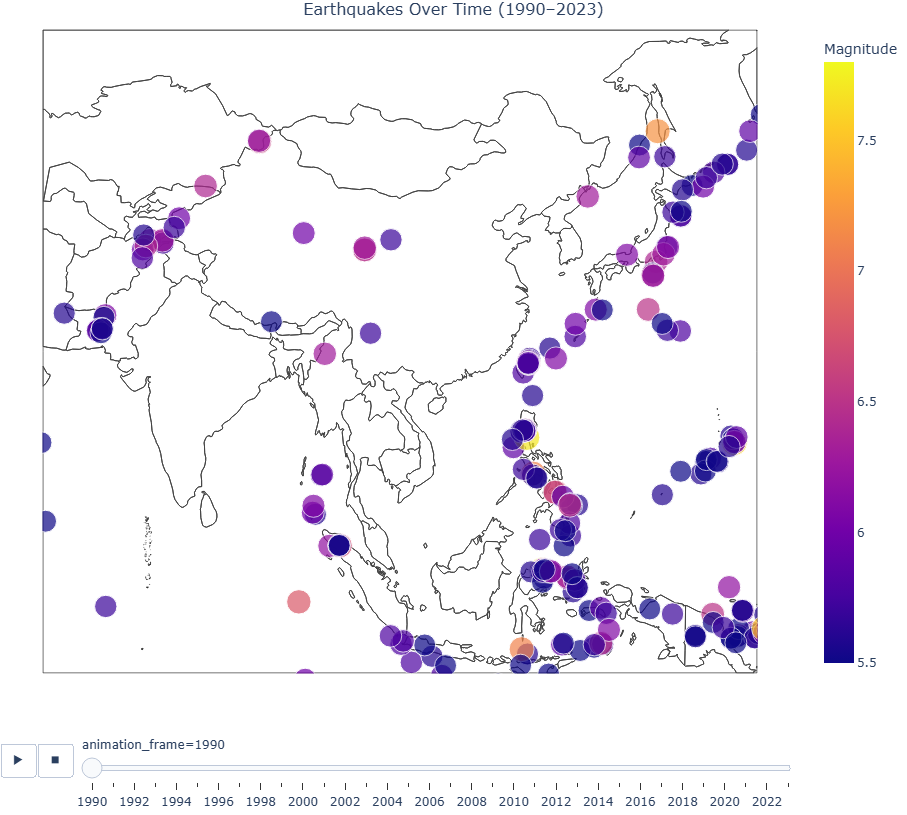

In [45]:
import plotly.express as px

# Create an animated scatter plot with Plotly Express
fig = px.scatter_geo(
    df_clean,
    lat='latitude',
    lon='longitude',
    size='mag',
    color='mag',
    animation_frame=df_clean['year'].astype(str),
    projection="natural earth",
    title="Earthquakes Over Time (1990–2023)",
    labels={'mag': 'Magnitude'},
    template='plotly_white'
)
# Update layout to make the figure larger
fig.update_layout(
    title_x=0.5,
    width=1200,  
    height=800, 
    title_font_size=16,  
    margin={"r":0,"t":30,"l":0,"b":0}, 
)

fig.update_geos(
    visible=True,
    resolution=50,
    showcountries=True,
    lataxis_range=[-10, 60],  # Latitude range for Asia
    lonaxis_range=[60, 150]   # Longitude range for Asia
)

fig.show()

fig.write_html(
    "earthquakes_over_time_asia.html",
    include_plotlyjs=True
)

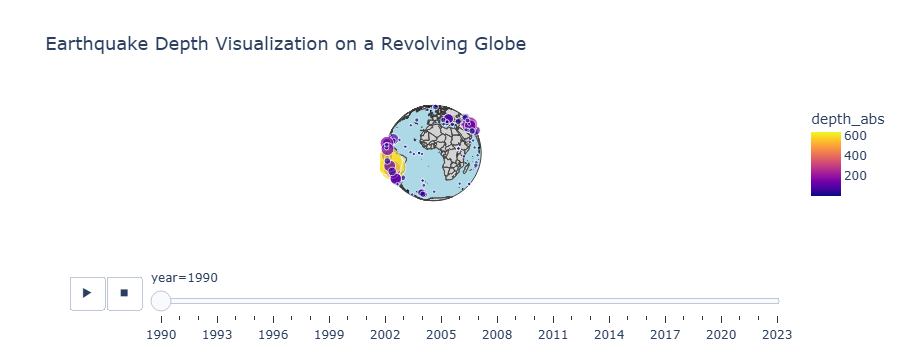

In [46]:
df_clean['depth_abs'] = df_clean['depth'].abs()
df_clean['scaled_depth'] = (df_clean['depth_abs'] / df_clean['depth_abs'].max()) * 100

# Create a 3D globe visualization with depth represented by point size
fig = px.scatter_geo(
    df_clean,
    lat='latitude',  
    lon='longitude',  
    size='scaled_depth', 
    color='depth_abs',  
    animation_frame='year',
    projection="orthographic",  
    title="Earthquake Depth Visualization on a Revolving Globe",
    labels={'depth': 'Depth (km)'},
)

# Customize layout for better visualization
fig.update_layout(
    title_font_size=18,
    geo=dict(
        showland=True,  # Show land areas
        landcolor="lightgray",  # Set land color
        oceancolor="lightblue",  # Set ocean color
        showocean=True,  # Show ocean areas
        projection_scale=0.9,  # Adjust scale for better fit on screen
        resolution=50,  # Higher resolution for better details
    )
)

# Add interactivity: enable rotation to make the globe revolve
fig.update_geos(projection_rotation=dict(lon=0, lat=0), showcountries=True)

# Show the plot
fig.show()

## Part 7 3D Earth Visual 

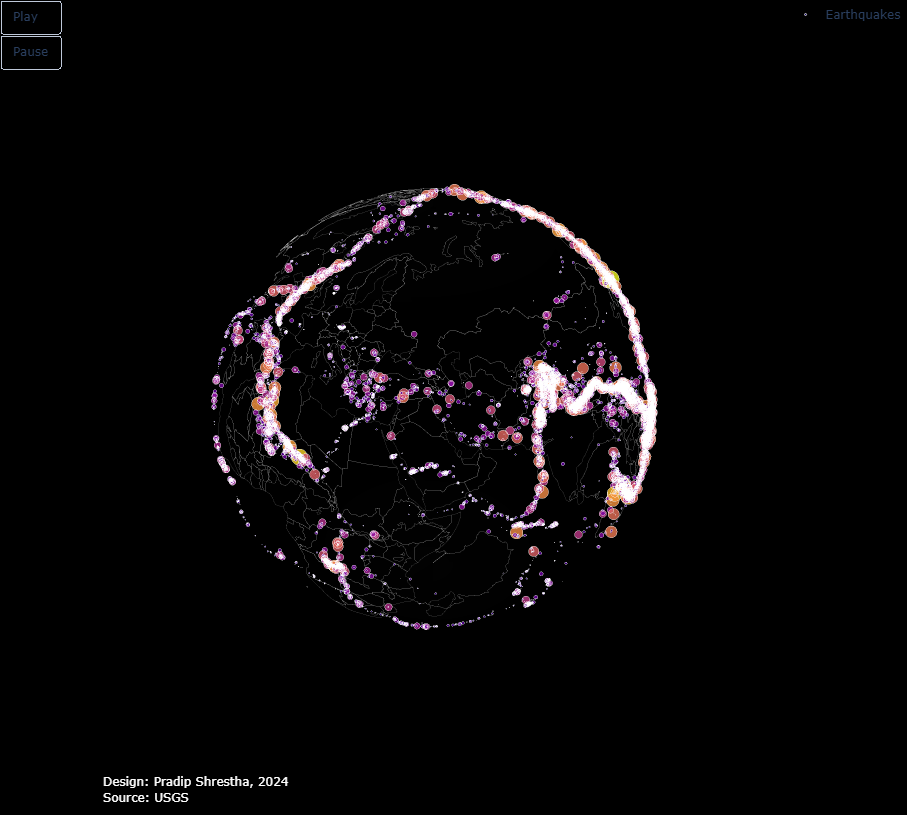

In [47]:
import geopandas as gpd
import plotly.graph_objects as go
import numpy as np
import os

# Load country boundaries from shapefile
world = gpd.read_file(r"C:\Users\pstha23\Documents\Python Scripts\ne_110m_admin_0_countries\ne_110m_admin_0_countries.shp")

# Earth's radius in kilometers
earth_radius = 6371

# Function to convert lat/lon to 3D Cartesian coordinates
def latlon_to_cartesian(lat, lon, radius=earth_radius):
    lat_rad = np.radians(lat)
    lon_rad = np.radians(lon)
    x = radius * np.cos(lat_rad) * np.cos(lon_rad)
    y = radius * np.cos(lat_rad) * np.sin(lon_rad)
    z = radius * np.sin(lat_rad)
    return x, y, z

# Extract boundary coordinates from GeoDataFrame
boundary_traces = []
for _, row in world.iterrows():
    if row['geometry'].geom_type == 'Polygon':  # Single polygon
        coords = np.array(row['geometry'].exterior.coords)
        lats, lons = coords[:, 1], coords[:, 0]
        x, y, z = latlon_to_cartesian(lats, lons)
        boundary_traces.append(go.Scatter3d(
            x=x, y=y, z=z,
            mode='lines',
            line=dict(color='white', width=1),
            opacity=0.2,
            showlegend=False
        ))
    elif row['geometry'].geom_type == 'MultiPolygon':  
        for polygon in row['geometry'].geoms:  
            coords = np.array(polygon.exterior.coords)
            lats, lons = coords[:, 1], coords[:, 0]
            x, y, z = latlon_to_cartesian(lats, lons)
            boundary_traces.append(go.Scatter3d(
                x=x, y=y, z=z,
                mode='lines',
                line=dict(color='white', width=1),
                opacity=0.3,
                showlegend=False
            ))

# Normalize earthquake magnitudes for marker size and brightness
df_clean['scaled_mag'] = (df_clean['mag'] - df_clean['mag'].min()) / (df_clean['mag'].max() - df_clean['mag'].min())
df_clean['marker_size'] = df_clean['scaled_mag'] * 20  
df_clean['brightness'] = df_clean['scaled_mag'] * 255  

# Convert latitude and longitude to spherical coordinates for earthquakes
df_clean['x'], df_clean['y'], df_clean['z'] = latlon_to_cartesian(df_clean['latitude'], df_clean['longitude'])

# Create hollow globe surface
theta = np.linspace(0, 2 * np.pi, 100)
phi = np.linspace(0, np.pi, 50)
theta, phi = np.meshgrid(theta, phi)

x_globe = earth_radius * np.sin(phi) * np.cos(theta)
y_globe = earth_radius * np.sin(phi) * np.sin(theta)
z_globe = earth_radius * np.cos(phi)

# Plot the globe and earthquake points
fig = go.Figure()

# Add hollow globe surface
fig.add_trace(go.Surface(
    x=x_globe,
    y=y_globe,
    z=z_globe,
    colorscale=[[0, "black"], [1, "black"]],  # Black hollow globe
    opacity=0.1,
    showscale=False,
    name='Earth Surface'
))

# Add country boundaries with low visibility
for trace in boundary_traces:
    fig.add_trace(trace)

# Add earthquake points with magnitude represented by size and brightness by color
fig.add_trace(go.Scatter3d(
    x=df_clean['x'],
    y=df_clean['y'],
    z=df_clean['z'],
    mode='markers',
    marker=dict(
        size=df_clean['marker_size'], 
        color=df_clean['brightness'],  
        colorscale='plasma', 
        opacity=0.8,
        showscale=False  # Remove color scale (legend)
    ),
    name='Earthquakes'
))


# Update layout to remove axes and focus on the globe
fig.update_layout(
    title=None,
    width=1200,  
    height=800,
    scene=dict(
        xaxis=dict(visible=False),  # Hide x-axis
        yaxis=dict(visible=False),  # Hide y-axis
        zaxis=dict(visible=False),  # Hide z-axis
        aspectmode='data'
    ),
    margin=dict(l=0, r=0, t=0, b=0),  
    paper_bgcolor="black"  
)

# Animate the globe by rotating it
frames = []
for angle in range(0, 360, 2): 
    frames.append(go.Frame(layout=dict(scene_camera=dict(eye=dict(x=np.cos(np.radians(angle)) * 1.5,
                                                                   y=np.sin(np.radians(angle)) * 1.5,
                                                                   z=1.5)))))

fig.frames = frames
fig.update_layout(
    updatemenus=[dict(type="buttons",
                      showactive=False,
                      buttons=[dict(label="Play",
                                    method="animate",
                                    args=[None, dict(frame=dict(duration=50, redraw=True), fromcurrent=True)]),
                               dict(label="Pause",
                                    method="animate",
                                    args=[[None], dict(frame=dict(duration=0, redraw=False), mode="immediate")])])])

# Add credits using annotations
fig.add_annotation(
    text="Design: Pradip Shrestha, 2024<br>Source: USGS", 
    showarrow=False,
    font=dict(size=12, color="white"),
    xref="paper", yref="paper", 
    x=0.01, y=0.01,   # Position at bottom-left corner (adjust as needed)
    align="left"
)

# Show the plot
fig.show()
